## Notebook to demo QR_Count.

In [1]:
# from spark_esri import spark_start, spark_stop

In [25]:
import os

import geofunctions as S
import geopandas as gp
import matplotlib.pyplot as plt
import pyspark.sql.functions as F

# import seaborn as sns
import xyzservices.providers as xyz

In [3]:
# config = {
#     "spark.driver.memory":"32G",
#     "spark.executor.memory":"32G",
#     "spark.jars":"geofunctions-0.6.jar",
# }

# spark_stop()
# spark = spark_start(config=config)

In [32]:
cell = 10.0  # QR in degrees.
dist = 0.00001  # Padding in degrees.
wkid = 4326

In [33]:
count = (
    spark.read.format("shp")
    .options(path="../data/world/tz_world.shp")
    .load()
    .repartition(200)
    .withColumn("count", S.qr_count("shape", cell, dist))
    .cache()
)

In [34]:
count.select("count").orderBy(F.col("count").desc()).limit(10).show(truncate=False)

+-----+
|count|
+-----+
|108  |
|24   |
|20   |
|16   |
|16   |
|15   |
|12   |
|12   |
|12   |
|12   |
+-----+



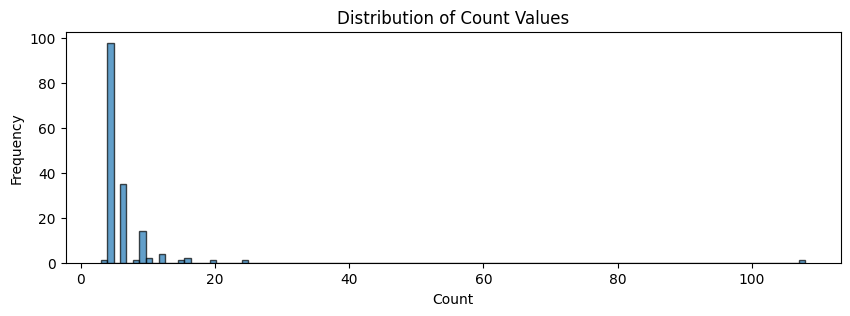

In [42]:
df_pandas = count.select("count").where(F.col("count") > 2).toPandas()

# Plot histogram using Matplotlib only
plt.figure(figsize=(10, 3))
plt.hist(df_pandas["count"], bins=110, edgecolor="black", alpha=0.7)

# Labels and title
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.title("Distribution of Count Values")

# Show the plot
plt.show()

In [40]:
summary_pd = count.select("count").where(F.col("count") > 2).summary().toPandas()
summary_pd

,summary,count
0,count,161
1,mean,6.248447204968944
2,stddev,8.624841343396277
3,min,3
4,25%,4
5,50%,4
6,75%,6
7,max,108


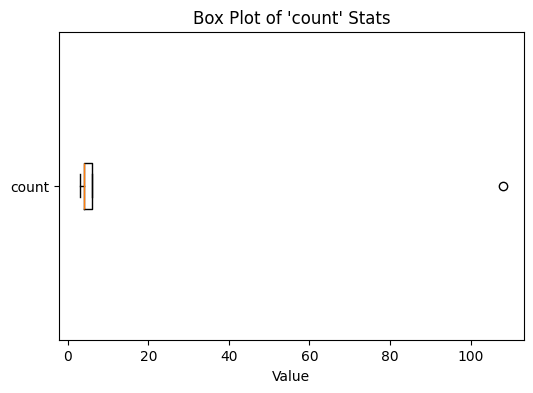

In [41]:
# Extract stats and convert to a format suitable for Matplotlib
summary_pd.set_index("summary", inplace=True)
cell_stats = summary_pd["count"].astype(float)  # Convert strings to floats
boxplot_data = [
    float(summary_pd.loc["min", "count"]),
    float(summary_pd.loc["25%", "count"]),  # Assuming percentile columns
    float(summary_pd.loc["50%", "count"]),  # Median
    float(summary_pd.loc["75%", "count"]),
    float(summary_pd.loc["max", "count"]),
]

# Plot the box plot
plt.figure(figsize=(6, 4))
plt.boxplot(boxplot_data, vert=False, tick_labels=["count"])
plt.title("Box Plot of 'count' Stats")
plt.xlabel("Value")
plt.show()